## Libraries

In [29]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import optuna

import wandb
from optuna.integration.wandb import WeightsAndBiasesCallback

import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier

## Load Files

In [93]:
df_train = pd.read_csv("data/raw/train.csv")
df_test = pd.read_csv("data/raw/test.csv")

df_train.head(10)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0
5,5,Vani,Female,59.0,Ahmedabad,Working Professional,Finanancial Analyst,NaN,2.0,NaN,NaN,5.0,5-6 hours,Healthy,MCA,No,7.0,5.0,No,0
6,6,Ritvik,Male,47.0,Thane,Working Professional,Chemist,NaN,5.0,NaN,NaN,2.0,7-8 hours,Moderate,MD,No,6.0,2.0,No,0
7,7,Rajveer,Male,38.0,Nashik,Working Professional,Teacher,NaN,3.0,NaN,NaN,4.0,7-8 hours,Unhealthy,B.Pharm,No,10.0,3.0,Yes,0
8,8,Aishwarya,Female,24.0,Bangalore,Student,NaN,2.0,NaN,5.90,5.0,NaN,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
9,9,Simran,Female,42.0,Patna,Working Professional,Electrician,NaN,4.0,NaN,NaN,1.0,5-6 hours,Healthy,ME,Yes,7.0,2.0,Yes,0


## **1. Reading and Understanding Data**

In [94]:
print(
    f"There are {df_train.shape[1]} columns and {df_train.shape[0]} rows in the train dataset."
)

There are 20 columns and 140700 rows in the train dataset.


### 1.1 What data type does each column currently have? Are there any columns whose data types are not suitable for further processing?

In [95]:
print("Column names and data type of each column:")
df_train.dtypes

Column names and data type of each column:


id                                         int64
Name                                      object
Gender                                    object
Age                                      float64
City                                      object
Working Professional or Student           object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object

### 1.2 Does the raw data have duplicate rows?

In [96]:
print("There are {} duplicates in the dataset.".format(df_train.duplicated().sum()))

There are 0 duplicates in the dataset.


### 1.3 Check the percentage of missing data in the columns

In [97]:
print("Checking for missing values in each column:")
# Percentage of missing data
missing_percentage = df_train.isnull().mean() * 100
print("Missing ratio")
print(missing_percentage)

Checking for missing values in each column:
Missing ratio
id                                        0.000000
Name                                      0.000000
Gender                                    0.000000
Age                                       0.000000
City                                      0.000000
Working Professional or Student           0.000000
Profession                               26.034115
Academic Pressure                        80.172708
Work Pressure                            19.842217
CGPA                                     80.171997
Study Satisfaction                       80.172708
Job Satisfaction                         19.836532
Sleep Duration                            0.000000
Dietary Habits                            0.002843
Degree                                    0.001421
Have you ever had suicidal thoughts ?     0.000000
Work/Study Hours                          0.000000
Financial Stress                          0.002843
Family History of Mental

### 1.4 For each column with numeric data type, how are the values distributed?

In [98]:
def missing_ratio(column):
    return column.isna().mean() * 100


def lower_quartile(column):
    return column.quantile(0.25)


def median(column):
    return column.median()


def upper_quartile(column):
    return column.quantile(0.75)


# Select numerical columns (float64, int64) from the DataFrame
numeric_cols = df_train.select_dtypes(include=["float64", "int64"]).columns

# Dictionary to store the statistics
statistics = {
    "missing_ratio": [],
    "min": [],
    "lower_quartile": [],
    "median": [],
    "upper_quartile": [],
    "max": [],
}

# Calculate statistics for each numerical column
for col in numeric_cols:
    missing_ratio_val = missing_ratio(df_train[col])
    min_val = df_train[col].min()
    lower_quartile_val = lower_quartile(df_train[col])
    median_val = median(df_train[col])
    upper_quartile_val = upper_quartile(df_train[col])
    max_val = df_train[col].max()

    statistics["missing_ratio"].append(missing_ratio_val)
    statistics["min"].append(min_val)
    statistics["lower_quartile"].append(lower_quartile_val)
    statistics["median"].append(median_val)
    statistics["upper_quartile"].append(upper_quartile_val)
    statistics["max"].append(max_val)

# Create a DataFrame from the statistics dictionary
num_col_info_df = pd.DataFrame(statistics, index=numeric_cols).T.round(1)
num_col_info_df

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
missing_ratio,0.0,0.0,80.2,19.8,80.2,80.2,19.8,0.0,0.0,0.0
min,0.0,18.0,1.0,1.0,5.0,1.0,1.0,0.0,1.0,0.0
lower_quartile,35174.8,29.0,2.0,2.0,6.3,2.0,2.0,3.0,2.0,0.0
median,70349.5,42.0,3.0,3.0,7.8,3.0,3.0,6.0,3.0,0.0
upper_quartile,105524.2,51.0,4.0,4.0,8.9,4.0,4.0,10.0,4.0,0.0
max,140699.0,60.0,5.0,5.0,10.0,5.0,5.0,12.0,5.0,1.0


### **1.5. For each column with a non-numeric data type, how are the values distributed?**

In [99]:
non_numeric_cols = df_train.select_dtypes(exclude=["float64", "int64"]).columns

# Thêm 'top_value' và 'top_freq' vào dictionary
cat_statistics = {
    "missing_ratio": [],
    "num_values": [],
    "top_value": [],
    "top_freq": [],
}

for col in non_numeric_cols:
    missing_ratio = df_train[col].isna().mean() * 100
    num_values = df_train[col].nunique()

    top_val = np.nan
    top_fr = 0  #

    # Chỉ tính khi cột có giá trị
    if num_values > 0:
        top_val = df_train[col].mode().iloc[0]  # .mode() trả về giá trị phổ biến nhất
        top_fr = df_train[col].value_counts().max()  # Tần suất của giá trị đó

    # Thêm kết quả vào
    cat_statistics["missing_ratio"].append(round(missing_ratio, 1))
    cat_statistics["num_values"].append(num_values)
    cat_statistics["top_value"].append(top_val)
    cat_statistics["top_freq"].append(top_fr)

cat_col_info_df = pd.DataFrame(cat_statistics, index=non_numeric_cols).T
cat_col_info_df

,Name,Gender,City,Working Professional or Student,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Family History of Mental Illness
missing_ratio,0.0,0.0,0.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0
num_values,422,2,98,2,64,36,23,115,2,2
top_value,Rohan,Male,Kalyan,Working Professional,Teacher,Less than 5 hours,Moderate,Class 12,No,No
top_freq,3178,77464,6591,112799,24906,38784,49705,14729,71138,70758


Describe: 

Describe

## **2. Preprocessing**

Sau khi kiểm tra dataset, nhóm nhận thấy rằng nhiều cột có tỷ lệ thiếu dữ liệu cao (trên 80%).
Tuy nhiên, sau khi phân tích theo biến Working Professional or Student, nhóm phát hiện rằng:

Các cột như Academic Pressure, CGPA, Study Satisfaction chỉ áp dụng cho Student, nên Working Professional không có dữ liệu → dẫn đến missing ~80%.

Ngược lại, các cột như Work Pressure, Job Satisfaction chỉ áp dụng cho Working Professional, nên nhóm Student không có dữ liệu → missing gần 100% trong nhóm này.

➡️ Do đó, việc thiếu dữ liệu là mang tính hệ thống (systematic missing), không phải lỗi của dataset.                                          

## Xử lý các cột bị thiếu. Các cột bị thiếu

| Cột | Tỷ lệ thiếu (%) | Kiểu dữ liệu |
| :--- | :--- | :--- |
| **Academic Pressure** | 80.17% | numeric |
| **CGPA** | 80.17% | numeric |
| **Study Satisfaction** | 80.17% | numeric |
| **Profession** | 26.03% | non-numeric |
| **Work Pressure** | 19.84% | numeric |
| **Job Satisfaction** | 19.84% | numeric |
| **Dietary Habits** | 0.003% | non-numeric |
| **Financial Stress** | 0.003% | numeric |
| **Degree** | 0.001% | non-numeric |

### Phía trên là các cột liên quan tới cột Working Professional or Student, nơi mà chỉ có 2 giá trị là Working Professional và Student. Thì đi cùng với nó sẽ là các cột 
- Academic Pressure (Student có dữ liệu, Working không)
- Work Pressure (Working có dữ liệu, Student không)
- CGPA (Student có dữ liệu, Working không)
- Study Satisfaction (Student có dữ liệu, Working không)
- Job Satisfaction (Working có dữ liệu, Student không)


In [100]:
# Các dòng mà cột Working Professional có giá trị là "Student" và "Working Professional"
df_train_students = df_train[df_train["Working Professional or Student"] == "Student"]
df_train_working = df_train[
    df_train["Working Professional or Student"] == "Working Professional"
]


def calc_missing_ratio(column):
    return column.isna().mean() * 100


# Tính missing ratio cho các cột numeric trong từng nhóm
# --- Phần cho Student ---
print("Missing ratios for numeric columns in Student group:")
numeric_cols_student = df_train_students.select_dtypes(
    include=["float64", "int64"]
).columns

for col in numeric_cols_student:
    missing_ratio_val_student = calc_missing_ratio(df_train_students[col])
    print(f"- {col}: {missing_ratio_val_student:.2f}%")


# --- Phần cho Working Professional ---
print(
    "\nMissing ratios for numeric columns in Working Professional group:"
)  # Thêm \n cho dễ nhìn
numeric_cols_working = df_train_working.select_dtypes(
    include=["float64", "int64"]
).columns

for col in numeric_cols_working:
    missing_ratio_val_working = calc_missing_ratio(df_train_working[col])
    print(f"- {col}: {missing_ratio_val_working:.2f}%")

Missing ratios for numeric columns in Student group:
- id: 0.00%
- Age: 0.00%
- Academic Pressure: 0.03%
- Work Pressure: 99.99%
- CGPA: 0.03%
- Study Satisfaction: 0.04%
- Job Satisfaction: 99.97%
- Work/Study Hours: 0.00%
- Financial Stress: 0.01%
- Depression: 0.00%

Missing ratios for numeric columns in Working Professional group:
- id: 0.00%
- Age: 0.00%
- Academic Pressure: 100.00%
- Work Pressure: 0.02%
- CGPA: 99.99%
- Study Satisfaction: 99.99%
- Job Satisfaction: 0.02%
- Work/Study Hours: 0.00%
- Financial Stress: 0.00%
- Depression: 0.00%


In [101]:
# Đối với các cột thiếu Academic Pressure, CGPA, Work Pressure, Study Satisfaction, Job Satisfaction,  ta sẽ điền giá trị 0 cho các dòng bị thiếu
cols_to_fill_zero = [
    "Academic Pressure",
    "CGPA",
    "Work Pressure",
    "Study Satisfaction",
    "Job Satisfaction",
]
for col in cols_to_fill_zero:
    df_train[col].fillna(0, inplace=True)
    df_test[col].fillna(0, inplace=True)

# Còn 1 cột Financial Stress bị thiếu, ta sẽ điền giá trị trung bình của cột này vào các dòng bị thiếu
mean_financial_stress = df_train["Financial Stress"].mean()
df_train["Financial Stress"].fillna(mean_financial_stress, inplace=True)
df_test["Financial Stress"].fillna(mean_financial_stress, inplace=True)
print("Missing values after imputation:")
print(df_train[cols_to_fill_zero + ["Financial Stress"]].isnull().sum())

train_cleaned = df_train.copy()
test_cleaned = df_test.copy()

Missing values after imputation:
Academic Pressure     0
CGPA                  0
Work Pressure         0
Study Satisfaction    0
Job Satisfaction      0
Financial Stress      0
dtype: int64


/var/folders/yf/bvb_cdgn46s4l8cp8l3wd_nc0000gn/T/ipykernel_77914/4244214699.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[col].fillna(0, inplace=True)
/var/folders/yf/bvb_cdgn46s4l8cp8l3wd_nc0000gn/T/ipykernel_77914/4244214699.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [102]:
# Đối với cột dữ liệu  non-numeric, thay bằng giá trị xuất hiện nhiều nhất (mode)
train_cleaned["Profession"].fillna(train_cleaned["Profession"].mode()[0], inplace=True)
test_cleaned["Profession"].fillna(test_cleaned["Profession"].mode()[0], inplace=True)
train_cleaned["Dietary Habits"].fillna(
    train_cleaned["Dietary Habits"].mode()[0], inplace=True
)
test_cleaned["Dietary Habits"].fillna(
    test_cleaned["Dietary Habits"].mode()[0], inplace=True
)
train_cleaned["Degree"].fillna(train_cleaned["Degree"].mode()[0], inplace=True)
test_cleaned["Degree"].fillna(test_cleaned["Degree"].mode()[0], inplace=True)

/var/folders/yf/bvb_cdgn46s4l8cp8l3wd_nc0000gn/T/ipykernel_77914/431855745.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_cleaned["Profession"].fillna(train_cleaned["Profession"].mode()[0], inplace=True)
/var/folders/yf/bvb_cdgn46s4l8cp8l3wd_nc0000gn/T/ipykernel_77914/431855745.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate objec

## Kiểm tra lại 

In [103]:
check_train = train_cleaned.isnull().sum()
check_test = test_cleaned.isnull().sum()
check_train

id                                       0
Name                                     0
Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [104]:
check_test

id                                       0
Name                                     0
Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
dtype: int64

# Feature engineering

In [105]:
# Create helper function to map sleep durations
print("Tổng số giá trị unique:", df_train["Sleep Duration"].nunique())
print("\nDanh sách các giá trị:")
print(df_train["Sleep Duration"].unique())


# 1. Định nghĩa hàm xử lý (giữ nguyên logic gom nhóm tốt nhất nãy giờ)
def map_sleep_duration(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower().strip()

    # --- NHÓM 1: Các giá trị chuẩn ---
    if (
        "less than 5" in x
        or "1-2 hours" in x
        or "2-3 hours" in x
        or "3-4 hours" in x
        or "1-3 hours" in x
        or "4-5 hours" in x
    ):
        return 4.5
    elif "5-6 hours" in x:
        return 5.5
    elif "6-7 hours" in x or "6-8 hours" in x or "1-6 hours" in x or "3-6 hours" in x:
        return 6.0
    elif "7-8 hours" in x or "8 hours" in x:
        return 7.5
    elif "8-9 hours" in x:
        return 8.5
    elif (
        "more than 8" in x
        or "9-11 hours" in x
        or "10-11 hours" in x
        or "9-5 hours" in x
        or "9-6 hours" in x
    ):
        return 9.0
    elif "4-6 hours" in x:
        return 5.0
    elif "than 5 hours" in x:
        return 4.5

    # --- NHÓM 2: Rác (Noise) -> Trả về NaN ---
    else:
        return np.nan


# 2. Áp dụng hàm để tạo cột số mới (lúc này vẫn còn NaN do các giá trị rác)
train_cleaned["SleepDuration_num"] = train_cleaned["Sleep Duration"].apply(
    map_sleep_duration
)
test_cleaned["SleepDuration_num"] = test_cleaned["Sleep Duration"].apply(
    map_sleep_duration
)

# 3. Tính giá trị TRUNG BÌNH (Mean) trên tập Train (chỉ tính trên các dòng có số liệu hợp lệ)
sleep_mean_val = train_cleaned["SleepDuration_num"].mean()
print(f"Giá trị trung bình giờ ngủ (tính từ tập Train): {sleep_mean_val:.2f} giờ")

# 4. Điền (Fill) các ô NaN bằng giá trị trung bình vừa tính
# Lưu ý: Phải điền vào cả tập Test bằng giá trị của tập Train
train_cleaned["SleepDuration_num"].fillna(sleep_mean_val, inplace=True)
test_cleaned["SleepDuration_num"].fillna(sleep_mean_val, inplace=True)

# Kiểm tra lại xem còn NaN không
print(
    "Số lượng NaN sau khi điền (Train):",
    train_cleaned["SleepDuration_num"].isna().sum(),
)

# 5. Tạo đặc trưng is_student
train_cleaned["is_student"] = (
    train_cleaned["Working Professional or Student"] == "Student"
).astype(int)
test_cleaned["is_student"] = (
    test_cleaned["Working Professional or Student"] == "Student"
).astype(int)

# 6. Xóa các cột cũ không dùng nữa
train_cleaned = train_cleaned.drop(
    columns=["Working Professional or Student", "Sleep Duration"]
)
test_cleaned = test_cleaned.drop(
    columns=["Working Professional or Student", "Sleep Duration"]
)

# Xem kết quả
train_cleaned.head(10)

Tổng số giá trị unique: 36

Danh sách các giá trị:
['More than 8 hours' 'Less than 5 hours' '5-6 hours' '7-8 hours'
 'Sleep_Duration' '1-2 hours' '6-8 hours' '4-6 hours' '6-7 hours'
 '10-11 hours' '8-9 hours' '40-45 hours' '9-11 hours' '2-3 hours'
 '3-4 hours' 'Moderate' '55-66 hours' '4-5 hours' '9-6 hours' '1-3 hours'
 'Indore' '45' '1-6 hours' '35-36 hours' '8 hours' 'No' '10-6 hours'
 'than 5 hours' '49 hours' 'Unhealthy' 'Work_Study_Hours' '3-6 hours'
 '45-48 hours' '9-5' 'Pune' '9-5 hours']
Giá trị trung bình giờ ngủ (tính từ tập Train): 6.22 giờ
Số lượng NaN sau khi điền (Train): 0


/var/folders/yf/bvb_cdgn46s4l8cp8l3wd_nc0000gn/T/ipykernel_77914/129428550.py:64: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_cleaned["SleepDuration_num"].fillna(sleep_mean_val, inplace=True)
/var/folders/yf/bvb_cdgn46s4l8cp8l3wd_nc0000gn/T/ipykernel_77914/129428550.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

,id,Name,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,SleepDuration_num,is_student
0,0,Aaradhya,Female,49.0,Ludhiana,Chef,0.0,5.0,0.00,0.0,2.0,Healthy,BHM,No,1.0,2.0,No,0,7.5,0
1,1,Vivan,Male,26.0,Varanasi,Teacher,0.0,4.0,0.00,0.0,3.0,Unhealthy,LLB,Yes,7.0,3.0,No,1,4.5,0
2,2,Yuvraj,Male,33.0,Visakhapatnam,Teacher,5.0,0.0,8.97,2.0,0.0,Healthy,B.Pharm,Yes,3.0,1.0,No,1,5.5,1
3,3,Yuvraj,Male,22.0,Mumbai,Teacher,0.0,5.0,0.00,0.0,1.0,Moderate,BBA,Yes,10.0,1.0,Yes,1,4.5,0
4,4,Rhea,Female,30.0,Kanpur,Business Analyst,0.0,1.0,0.00,0.0,1.0,Unhealthy,BBA,Yes,9.0,4.0,Yes,0,5.5,0
5,5,Vani,Female,59.0,Ahmedabad,Finanancial Analyst,0.0,2.0,0.00,0.0,5.0,Healthy,MCA,No,7.0,5.0,No,0,5.5,0
6,6,Ritvik,Male,47.0,Thane,Chemist,0.0,5.0,0.00,0.0,2.0,Moderate,MD,No,6.0,2.0,No,0,7.5,0
7,7,Rajveer,Male,38.0,Nashik,Teacher,0.0,3.0,0.00,0.0,4.0,Unhealthy,B.Pharm,No,10.0,3.0,Yes,0,7.5,0
8,8,Aishwarya,Female,24.0,Bangalore,Teacher,2.0,0.0,5.90,5.0,0.0,Moderate,BSc,No,3.0,2.0,Yes,0,5.5,1
9,9,Simran,Female,42.0,Patna,Electrician,0.0,4.0,0.00,0.0,1.0,Healthy,ME,Yes,7.0,2.0,Yes,0,5.5,0


In [106]:
train_cleaned.dtypes

id                                         int64
Name                                      object
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
SleepDuration_num                        float64
is_student                                 int64
dtype: object

In [107]:
train_cleaned.to_csv("data/preprocessed/train_cleaned.csv", index=False)
test_cleaned.to_csv("data/preprocessed/test_cleaned.csv", index=False)

In [ ]:
# Read data
train_final = pd.read_csv("data/preprocessed/train_cleaned.csv")
test_final = pd.read_csv("data/preprocessed/test_cleaned.csv")

In [4]:
print(
    f"Tập train có {train_final.shape[0]} mẫu dữ liệu, mỗi mẫu có {train_final.shape[1]} biến, trong đó có 1 biến là biến mục tiêu."
)
print(
    f"Tập test có {test_final.shape[0]} mẫu dữ liệu, mỗi mẫu có {test_final.shape[1]} biến."
)

Tập train có 140700 mẫu dữ liệu, mỗi mẫu có 20 biến, trong đó có 1 biến là biến mục tiêu.
Tập test có 93800 mẫu dữ liệu, mỗi mẫu có 19 biến.


In [5]:
# Encode các cột có câu trả lời Yes No
yes_no_cols = [
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness",
]

for col in yes_no_cols:
    train_final[col] = train_final[col].map({"Yes": 1, "No": 0})
    test_final[col] = test_final[col].map({"Yes": 1, "No": 0})

In [6]:
# Encode cột giới tính sinh học (Gender)
train_final["Gender"] = train_final["Gender"].map({"Male": 1, "Female": 0})
test_final["Gender"] = test_final["Gender"].map({"Male": 1, "Female": 0})

In [7]:
# Encode các cột biến phân loại còn lại
label_cols = ["Profession", "Dietary Habits", "Degree", "City"]
for col in label_cols:
    label_encoder = LabelEncoder()
    combines_cols = pd.concat([train_final[col], test_final[col]], axis=0).astype(str)
    label_encoder.fit(combines_cols)
    train_final[col] = label_encoder.transform(train_final[col].astype(str))
    test_final[col] = label_encoder.transform(test_final[col].astype(str))

# Final feature list
train_final.columns.tolist()

['id',
 'Name',
 'Gender',
 'Age',
 'City',
 'Profession',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Work/Study Hours',
 'Financial Stress',
 'Family History of Mental Illness',
 'Depression',
 'SleepDuration_num',
 'is_student']

In [8]:
# Loại bỏ cột 'Depression' (target) và các cột định danh không có giá trị dự đoán
cols_to_drop = ["id", "Name"]

X = train_final.drop(columns=["Depression"] + cols_to_drop)
y = train_final["Depression"]

# X_test dùng để nộp bài sau này (chỉ bỏ cột id, Name)
X_test_submission = test_final.drop(columns=cols_to_drop)

In [9]:
test_final

,id,Name,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,SleepDuration_num,is_student
0,140700,Shivam,1,53.0,123,35,0.0,2.0,0.00,0.0,5.0,22,92,0,9.0,3.0,1,4.5,0
1,140701,Sanya,0,58.0,53,25,0.0,2.0,0.00,0.0,4.0,22,31,0,6.0,4.0,0,4.5,0
2,140702,Yash,1,53.0,42,71,0.0,4.0,0.00,0.0,1.0,22,26,1,12.0,4.0,0,7.5,0
3,140703,Nalini,0,23.0,95,71,5.0,0.0,6.84,1.0,0.0,22,53,1,10.0,4.0,0,7.5,1
4,140704,Shaurya,1,47.0,45,71,0.0,5.0,0.00,0.0,5.0,22,45,1,3.0,4.0,0,7.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93795,234495,Zoya,0,49.0,42,58,0.0,3.0,0.00,0.0,5.0,22,53,1,2.0,2.0,1,4.5,0
93796,234496,Shlok,1,29.0,6,58,0.0,5.0,0.00,0.0,1.0,22,46,1,11.0,3.0,1,7.5,0
93797,234497,Rishi,1,24.0,123,71,1.0,0.0,7.51,4.0,0.0,22,39,0,7.0,1.0,0,7.5,1
93798,234498,Eshita,0,23.0,45,48,0.0,4.0,0.00,0.0,2.0,11,41,1,7.0,5.0,1,5.5,0


In [10]:
X_test_submission.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,SleepDuration_num,is_student
0,1,53.0,123,35,0.0,2.0,0.00,0.0,5.0,22,92,0,9.0,3.0,1,4.5,0
1,0,58.0,53,25,0.0,2.0,0.00,0.0,4.0,22,31,0,6.0,4.0,0,4.5,0
2,1,53.0,42,71,0.0,4.0,0.00,0.0,1.0,22,26,1,12.0,4.0,0,7.5,0
3,0,23.0,95,71,5.0,0.0,6.84,1.0,0.0,22,53,1,10.0,4.0,0,7.5,1
4,1,47.0,45,71,0.0,5.0,0.00,0.0,5.0,22,45,1,3.0,4.0,0,7.5,0


In [11]:
# 2. Chia tập dữ liệu (80% để học, 20% để thi thử)
# stratify=y giúp đảm bảo tỷ lệ người bị trầm cảm ở 2 tập là như nhau
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Val:", X_val.shape)

Kích thước tập Train: (112560, 17)
Kích thước tập Val: (28140, 17)


In [117]:
X_train.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,SleepDuration_num,is_student
3429,0,25.0,53,71,5.0,0.0,5.59,5.0,0.0,22,117,1,8.0,5.0,0,4.5,1
57741,0,20.0,21,71,3.0,0.0,8.27,4.0,0.0,32,66,0,0.0,1.0,1,5.5,1
83234,1,24.0,115,71,3.0,0.0,6.00,2.0,0.0,11,30,0,3.0,1.0,1,7.5,1
136573,0,38.0,53,19,0.0,1.0,0.00,0.0,3.0,22,106,0,10.0,2.0,1,4.5,0
93261,0,24.0,6,71,4.0,0.0,8.04,4.0,0.0,11,26,1,10.0,3.0,1,7.5,1


In [118]:
# # Lưu lại tập train với test để dùng thống nhất cho các model khác nhau, tránh trường hợp mỗi model học 1 kiểu
# X_train.to_csv("data/preprocessed/X_train.csv")
# X_val.to_csv("data/preprocessed/X_val.csv")
# y_train.to_csv("data/preprocessed/y_train.csv")
# y_val.to_csv("data/preprocessed/y_val.csv")

# Model

## Bắt đầu với model baseline
- RandomForest 

In [153]:
# Đọc data từ các file đã lưu
X_train = pd.read_csv("data/preprocessed/X_train.csv", index_col=0)
X_val = pd.read_csv("data/preprocessed/X_val.csv", index_col=0)
y_train = pd.read_csv("data/preprocessed/y_train.csv", index_col=0)
y_val = pd.read_csv("data/preprocessed/y_val.csv", index_col=0)

/Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/NĂM 4/HKI/Intelligent Data Analysis/Chatbot_Extension/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


KẾT QUẢ BASELINE (Random Forest)
Accuracy: 0.9368
F1-Score: 0.8910
ROC-AUC: 0.8812
Average Precision: 0.7111

Chi tiết báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     23027
           1       0.85      0.79      0.82      5113

    accuracy                           0.94     28140
   macro avg       0.90      0.88      0.89     28140
weighted avg       0.94      0.94      0.94     28140



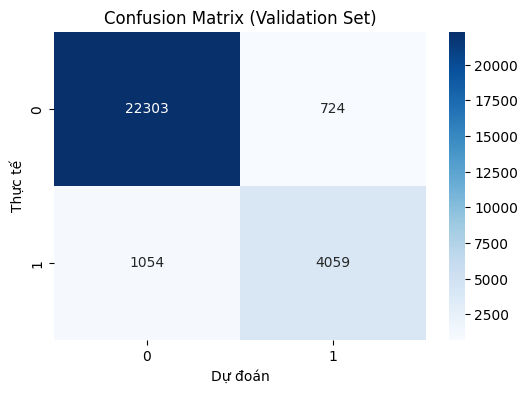

In [ ]:
# 3. Khởi tạo và huấn luyện mô hình Random Forest
# n_estimators=100: Dùng 100 cây quyết định
# random_state=42: Giữ kết quả ổn định mỗi lần chạy
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# 4. Dự đoán và đánh giá trên tập Validation
y_pred = rf_model.predict(X_val)

# In kết quả
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average="macro")
roc = roc_auc_score(y_val, y_pred)
ap = average_precision_score(y_val, y_pred)

print("KẾT QUẢ BASELINE (Random Forest)")
print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print(f"Average Precision: {ap:.4f}")
print("\nChi tiết báo cáo phân loại:")
print(classification_report(y_val, y_pred))

# Vẽ Confusion Matrix để xem mô hình hay nhầm lẫn ở đâu
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Validation Set)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show();

/var/folders/yf/bvb_cdgn46s4l8cp8l3wd_nc0000gn/T/ipykernel_77914/1161442306.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


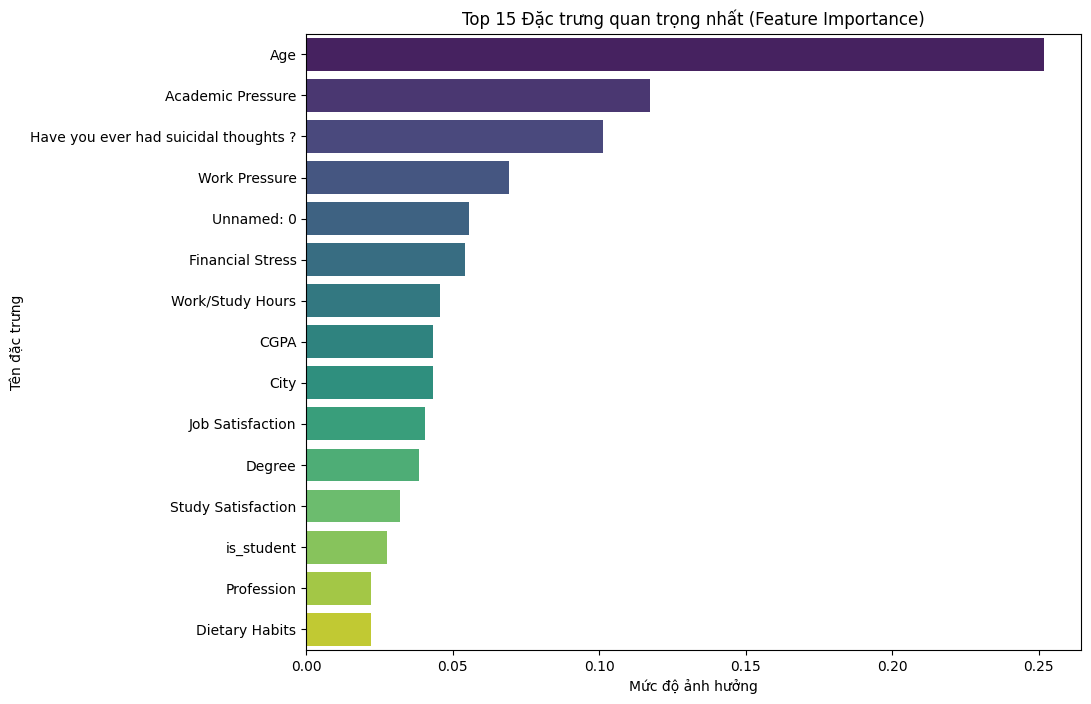

                                  Feature  Importance
2                                     Age    0.251923
5                       Academic Pressure    0.117512
12  Have you ever had suicidal thoughts ?    0.101236
6                           Work Pressure    0.069345
0                              Unnamed: 0    0.055654
14                       Financial Stress    0.054047
13                       Work/Study Hours    0.045553
7                                    CGPA    0.043427
3                                    City    0.043147
9                        Job Satisfaction    0.040599


In [168]:
# 1. Lấy mức độ quan trọng của các features
importances = rf_model.feature_importances_
feature_names = X_train.columns

# 2. Tạo DataFrame để dễ vẽ
feature_importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.barplot(
    x="Importance", y="Feature", data=feature_importance_df.head(15), palette="viridis"
)  # Top 15
plt.title("Top 15 Đặc trưng quan trọng nhất (Feature Importance)")
plt.xlabel("Mức độ ảnh hưởng")
plt.ylabel("Tên đặc trưng")
plt.show()
# In ra giá trị cụ thể
print(feature_importance_df.head(10))

Sau khi thực hiện quá trình Tiền xử lý (Preprocessing) và Kỹ thuật đặc trưng (Feature Engineering), nhóm đã tiến hành xây dựng và đánh giá mô hình Baseline. 
### 1. Model Selection
- Random Forest Classifier
- Lý do chọn 
    * Khả năng chống chịu nhiễu tốt (Robust to noise), phù hợp với dữ liệu có nhiều biến động như `Sleep Duration`.
    * Không yêu cầu chuẩn hóa dữ liệu (Scaling) khắt khe như các thuật toán khác (SVM, KNN).
    * Cung cấp **Feature Importance** giúp giải thích mức độ ảnh hưởng của từng yếu tố.
    * Hạn chế Overfitting tốt hơn so với Decision Tree đơn lẻ.

### 2. Thiết lập Thực nghiệm (Experimental Setup)
-  Chia tập Train/Val tỉ lệ 80/20
* **Kỹ thuật chia:** `stratify=y` để đảm bảo tỷ lệ nhãn lớp (người bị trầm cảm/không bị) cân bằng giữa hai tập, tránh thiên lệch khi đánh giá.
* **Xử lý dữ liệu:**
    * Đã loại bỏ các cột định danh vô nghĩa (`id`, `Name`) để tránh Data Leakage.
    * Các biến phân loại (`City`, `Profession`...) được mã hóa bằng Label Encoding.
    * Đặc biệt: Cột `Sleep Duration` đã được làm sạch và chuyển sang dạng số (`SleepDuration_num`), xử lý triệt để các giá trị lỗi.

### 3. Đánh giá Hiệu suất (Performance Evaluation)
Kết quả trên tập Validation (20% dữ liệu):
* **Accuracy:** `92.70%` - Mô hình có độ chính xác tổng thể rất cao.
* **F1-Score (cho lớp bị Trầm cảm - 1):** []
    * Đây là chỉ số quan trọng nhất trong bài toán y tế (tránh bỏ sót bệnh nhân). Mức 79% là khởi đầu rất khả quan cho một mô hình chưa tinh chỉnh tham số.
* **Confusion Matrix:** Tỷ lệ dự báo đúng lớp "Không trầm cảm" (Class 0) rất cao (Recall 0.96), tuy nhiên vẫn còn bỏ sót khoảng 23% số ca thực sự bị trầm cảm (Recall Class 1 là 0.77).

### 4. Phân tích Đặc trưng (Feature Analysis)
Dựa trên biểu đồ **Feature Importance**, các yếu tố ảnh hưởng nhất đến dự đoán là:
1.  **`Age` (Tuổi tác):** Chiếm trọng số cao nhất (~0.29), cho thấy độ tuổi là yếu tố phân loại mạnh mẽ.
2.  **`Suicidal Thoughts`:** Có mối tương quan chặt chẽ với trầm cảm (điều này phù hợp với kiến thức y khoa).
3.  **`is_student`:** Feature mới được tạo ra (phân biệt Sinh viên/Người đi làm) đứng Top 3 quan trọng, chứng minh giả thuyết ban đầu rằng áp lực của hai nhóm đối tượng này khác nhau là đúng.
4.  **`City`:** Cũng đóng góp đáng kể, gợi ý rằng môi trường sống có tác động đến sức khỏe tâm thần.



## Model nâng cao

- Catboost

In [21]:
# Xác định tên các cột là dữ liệu phân loại (Categorical)
cat_features_names = [
    "City",
    "Profession",
    "Dietary Habits",
    "Degree",
    "Gender",
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness",
    "is_student",
]

# Khi đọc dữ liệu lại bằng pandas thì các biến categorical tự động chuyển thành float
# nên ta phải chuyển lại thành int
# Convert categorical columns to integer type to fix CatBoost float issue
for col in cat_features_names:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(int)
        X_val[col] = X_val[col].astype(int)

In [22]:
cat_features_indices = [
    X_train.columns.get_loc(c) for c in cat_features_names if c in X_train.columns
]
print(f"Đã tìm thấy {len(cat_features_indices)} đặc trưng phân loại để tối ưu hóa.")

Đã tìm thấy 8 đặc trưng phân loại để tối ưu hóa.


In [23]:
cat_features_indices

[2, 3, 9, 10, 0, 11, 14, 16]

In [24]:
# Khởi tạo mô hình
# iterations: Số lượng cây (giống n_estimators)
# learning_rate: Tốc độ học (thấp thì chậm nhưng kỹ)
# depth: Độ sâu của cây
# early_stopping_rounds: Dừng nếu sau 50 vòng không thấy tốt hơn (chống overfitting)
cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="TotalF1:average=Macro",  # Tối ưu hóa trực tiếp cho điểm F1
    random_seed=42,
    verbose=200,  # In kết quả sau mỗi 200 vòng lặp
    auto_class_weights="Balanced",  # Tự động cân bằng trọng số (Rất tốt cho dữ liệu lệch như Depression)
)

In [25]:
print("\n=== BẮT ĐẦU HUẤN LUYỆN CATBOOST ===")
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features_indices,  # Báo cho model biết các cột phân loại
    eval_set=(X_val, y_val),
    early_stopping_rounds=100,
)
print("Huấn luyện hoàn tất!")


=== BẮT ĐẦU HUẤN LUYỆN CATBOOST ===
0:	learn: 0.8971216	test: 0.8957002	best: 0.8957002 (0)	total: 95.4ms	remaining: 3m 10s
200:	learn: 0.9232312	test: 0.9199728	best: 0.9200705 (193)	total: 6.27s	remaining: 56.1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9208525176
bestIteration = 285

Shrink model to first 286 iterations.
Huấn luyện hoàn tất!


In [26]:
# ĐÁNH GIÁ KẾT QUẢ
# Dự đoán trên tập Validation
y_pred_cat = cat_model.predict(X_val)

# Tính toán chỉ số
acc_cat = accuracy_score(y_val, y_pred_cat)
f1_cat = f1_score(y_val, y_pred_cat, average="macro")
roc_cat = roc_auc_score(y_val, y_pred_cat)
ap_cat = average_precision_score(y_val, y_pred_cat)

In [27]:
print("\n=== KẾT QUẢ CATBOOST ===")
print(f"Accuracy: {acc_cat:.4f}")
print(f"F1-Score: {f1_cat:.4f}")
print(f"ROC-AUC: {roc_cat:.4f}")
print(f"Average Precision: {ap_cat:.4f}")
print("\nChi tiết báo cáo phân loại:")
print(classification_report(y_val, y_pred_cat))


=== KẾT QUẢ CATBOOST ===
Accuracy: 0.9159
F1-Score: 0.8736
ROC-AUC: 0.9209
Average Precision: 0.6663

Chi tiết báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.98      0.91      0.95     23027
           1       0.70      0.93      0.80      5113

    accuracy                           0.92     28140
   macro avg       0.84      0.92      0.87     28140
weighted avg       0.93      0.92      0.92     28140



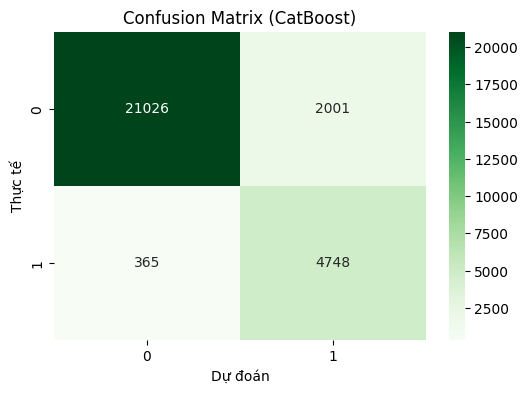

In [30]:
# Vẽ Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred_cat), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix (CatBoost)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()

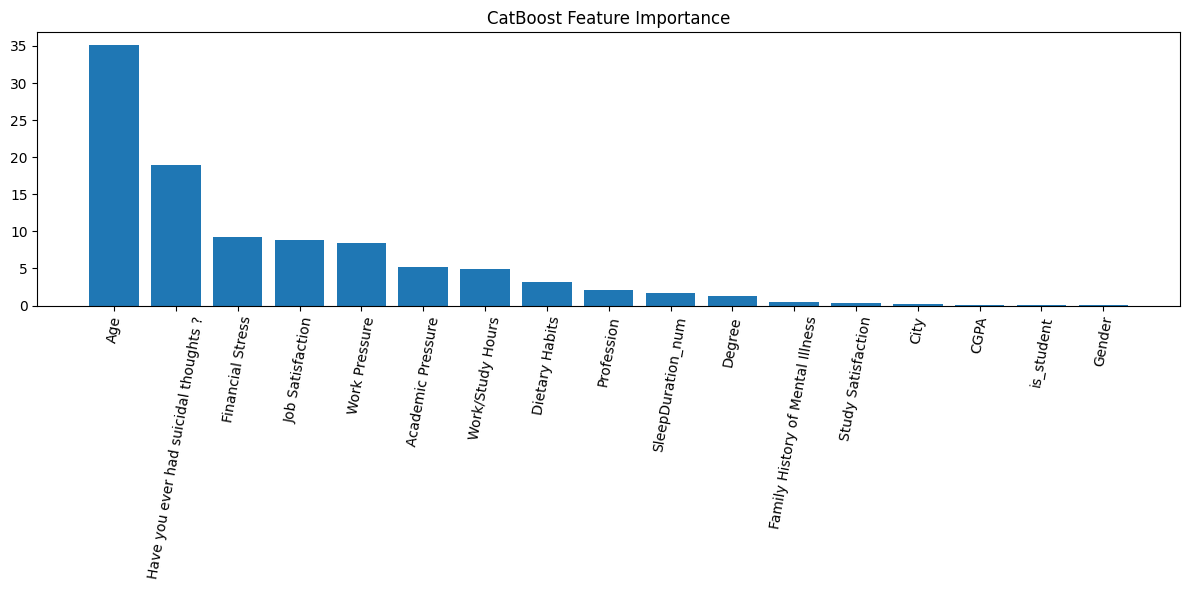

In [31]:
# Vẽ Feature Importance (Của CatBoost)
feature_importance = cat_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance[sorted_idx], align="center")
plt.xticks(
    range(len(feature_importance)), np.array(X_train.columns)[sorted_idx], rotation=80
)
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()

In [32]:
wandb_kwargs = {
    "entity": "team-csc17001-ida",
    "project": "depression-detection",
    "name": "optuna_catboost_study1",
}

wandb_callback = WeightsAndBiasesCallback(
    metric_name="valid_f1_macro",  # how the metric will be called in W&B
    wandb_kwargs=wandb_kwargs,  # passed to wandb.init(...)
    as_multirun=False,  # one W&B run for entire study
)

/var/folders/yf/bvb_cdgn46s4l8cp8l3wd_nc0000gn/T/ipykernel_68074/1476200886.py:7: ExperimentalWarning: WeightsAndBiasesCallback is experimental (supported from v2.9.0). The interface can change in the future.
  wandb_callback = WeightsAndBiasesCallback(
wandb: Currently logged in as: themetasetter (themetasetter-i-h-c-qu-c-gia-tp-hcm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [35]:
@wandb_callback.track_in_wandb()
def objective(trial):
    # Suggest hyperparameters
    iterations = trial.suggest_int("iterations", 500, 3000, step=500)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1, step=0.01)
    depth = trial.suggest_int("depth", 4, 10)

    # Treat threshold as a hyperparameter
    threshold = trial.suggest_float("threshold", 0.1, 0.9)

    # Initialize and train CatBoost model
    model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        loss_function="Logloss",
        eval_metric="TotalF1:average=Macro",  # Tối ưu hóa trực tiếp cho điểm F1
        random_seed=607,
        verbose=200,  # In kết quả sau mỗi 200 vòng lặp
        auto_class_weights="Balanced",  # Tự động cân bằng trọng số (Rất tốt cho dữ liệu lệch như Depression)
    )
    model.fit(X_train, y_train)

    # Get predicted probabilities
    y_pred_probs = model.predict_proba(X_val)[:, 1]
    # Apply threshold to get class predictions
    y_pred = (y_pred_probs >= threshold).astype(int)

    roc_auc = roc_auc_score(y_val, y_pred_probs)
    f1_macro = f1_score(y_val, y_pred, average="macro")
    average_precision = average_precision_score(y_val, y_pred_probs)
    accuracy = accuracy_score(y_val, y_pred)

    # Log to W&B
    wandb.log(
        {
            "valid_auc": roc_auc,
            "valid_ap": average_precision,
            "valid_f1_macro": f1_macro,
            "valid_accuracy": accuracy,
            "threshold": threshold,
        }
    )

    return f1_macro

/var/folders/yf/bvb_cdgn46s4l8cp8l3wd_nc0000gn/T/ipykernel_68074/2779495875.py:1: ExperimentalWarning: optuna_integration.wandb.wandb.WeightsAndBiasesCallback.track_in_wandb is experimental (supported from v3.0.0). The interface can change in the future.
  @wandb_callback.track_in_wandb()


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, callbacks=[wandb_callback], n_jobs=1)
wandb.finish()

In [37]:
best_params = study.best_params
best_score = study.best_value
print(f"Best Hyperparameters: {best_params}")
print(f"Best Accuracy: {best_score:.6f}")

# Get each best hyperparameter
iterations = best_params["iterations"]
learning_rate = best_params["learning_rate"]
depth = best_params["depth"]
threshold = best_params["threshold"]

Best Hyperparameters: {'iterations': 2000, 'learning_rate': 0.01, 'depth': 7, 'threshold': 0.77312897607623}
Best Accuracy: 0.896967


In [38]:
# Raise lỗi ở đây để dừng sau khi tối ưu xong
raise SystemExit("Đã hoàn tất tối ưu hyperparameter với Optuna và WandB.")

SystemExit: Đã hoàn tất tối ưu hyperparameter với Optuna và WandB.

/Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/NĂM 4/HKI/Intelligent Data Analysis/Chatbot_Extension/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [39]:
best_params

{'iterations': 2000,
 'learning_rate': 0.01,
 'depth': 7,
 'threshold': 0.77312897607623}

In [40]:
X.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,SleepDuration_num,is_student
0,0,49.0,62,13,0.0,5.0,0.00,0.0,2.0,11,50,0,1.0,2.0,0,7.5,0
1,1,26.0,118,71,0.0,4.0,0.00,0.0,3.0,32,92,1,7.0,3.0,0,4.5,0
2,1,33.0,123,71,5.0,0.0,8.97,2.0,0.0,11,34,1,3.0,1.0,0,5.5,1
3,1,22.0,79,71,0.0,5.0,0.00,0.0,1.0,22,44,1,10.0,1.0,1,4.5,0
4,0,30.0,46,12,0.0,1.0,0.00,0.0,1.0,32,44,1,9.0,4.0,1,5.5,0


In [41]:
X_train.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,SleepDuration_num,is_student
3429,0,25.0,53,71,5.0,0.0,5.59,5.0,0.0,22,117,1,8.0,5.0,0,4.5,1
57741,0,20.0,21,71,3.0,0.0,8.27,4.0,0.0,32,66,0,0.0,1.0,1,5.5,1
83234,1,24.0,115,71,3.0,0.0,6.00,2.0,0.0,11,30,0,3.0,1.0,1,7.5,1
136573,0,38.0,53,19,0.0,1.0,0.00,0.0,3.0,22,106,0,10.0,2.0,1,4.5,0
93261,0,24.0,6,71,4.0,0.0,8.04,4.0,0.0,11,26,1,10.0,3.0,1,7.5,1


In [42]:
# Retrain model with best hyperparameters on full training data
final_model = CatBoostClassifier(
    iterations=iterations,
    learning_rate=learning_rate,
    depth=depth,
    loss_function="Logloss",
    eval_metric="TotalF1:average=Macro",
    random_seed=607,
    verbose=200,
    auto_class_weights="Balanced",
)
final_model.fit(X, y)

0:	learn: 0.8944138	total: 24.4ms	remaining: 48.8s
200:	learn: 0.9177675	total: 2.93s	remaining: 26.2s
400:	learn: 0.9211835	total: 5.41s	remaining: 21.6s
600:	learn: 0.9231604	total: 7.94s	remaining: 18.5s
800:	learn: 0.9244073	total: 10.6s	remaining: 15.9s
1000:	learn: 0.9252785	total: 13.3s	remaining: 13.2s
1200:	learn: 0.9262604	total: 15.7s	remaining: 10.5s
1400:	learn: 0.9270426	total: 18.6s	remaining: 7.94s
1600:	learn: 0.9278203	total: 21.6s	remaining: 5.38s
1800:	learn: 0.9286501	total: 24.2s	remaining: 2.68s
1999:	learn: 0.9294407	total: 26.8s	remaining: 0us


In [43]:
# Get predicted probabilities
y_pred_probs = final_model.predict_proba(X_val)[:, 1]
# Apply threshold to get class predictions
y_pred = (y_pred_probs >= threshold).astype(int)

In [44]:
# Get metrics
roc_auc = roc_auc_score(y_val, y_pred_probs)
f1_macro = f1_score(y_val, y_pred, average="macro")
average_precision = average_precision_score(y_val, y_pred_probs)
accuracy = accuracy_score(y_val, y_pred)

# Print metrics
print("\n=== KẾT QUẢ CATBOOST TỐI ƯU HÓA ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1_macro:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")


=== KẾT QUẢ CATBOOST TỐI ƯU HÓA ===
Accuracy: 0.9424
F1-Score: 0.9034
ROC-AUC: 0.9791
Average Precision: 0.9190


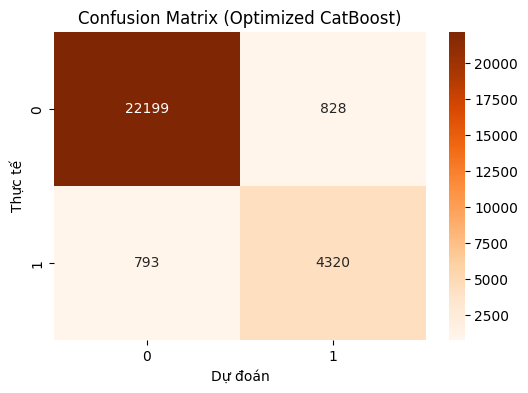

In [45]:
# Get confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix (Optimized CatBoost)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()

In [46]:
# Get classification report
print("\nChi tiết báo cáo phân loại:")
print(classification_report(y_val, y_pred))


Chi tiết báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96     23027
           1       0.84      0.84      0.84      5113

    accuracy                           0.94     28140
   macro avg       0.90      0.90      0.90     28140
weighted avg       0.94      0.94      0.94     28140

